In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)

from functools import partial

# timing and progress bars
from timeit import default_timer as timer
from tqdm import tqdm

# numerics
import jax
import jax.numpy as jnp
import optimistix as optx
import equinox as eqx
import optax
from flax.training.checkpoints import save_checkpoint

from jax import jit

from flow_CrossAttentionSetTransformer import Flow
from dataloader import OdisseoOTAllParametersPosition_newprior


In [ ]:
dataloader_train = OdisseoOTAllParametersPosition_newprior(
            DATA_ROOT = '/export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior',
            num_samples= 100_000,
            split= [0, 94999],
            seed= 0,
            num_steps = 2000,
            batch_size = 128,
            use_jax = False)

dataloader_val = OdisseoOTAllParametersPosition_newprior(
            DATA_ROOT = '/export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior',
            num_samples= 100_000,
            split= [95000, 99999],
            seed= 0,
            num_steps= 1000,
            batch_size= 64,
            use_jax = False)

odisseo_AllParametersPosition_newprior
DATA_ROOT: /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior/
Loading odisseo_AllParametersPosition_newprior locally from existing directory /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior
using numpy to load
using numpy to load
Dataloader sampling without replacements (num_steps: 743)
odisseo_AllParametersPosition_newprior
DATA_ROOT: /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior/
Loading odisseo_AllParametersPosition_newprior locally from existing directory /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior
using numpy to load
using numpy to load
Dataloader sampling without replacements (num_steps: 40)


In [ ]:
# ============================
# Initialization
# ============================

SEED = 5678
dim_flow = 13
N_dim = 64
N_head = 4
depth = 3
key = jax.random.PRNGKey(SEED)
key, subkey = jax.random.split(key, 2)
flow = Flow(dim_flow=dim_flow,
            N_dim=N_dim,
            N_head=N_head, 
            depth=depth, 
            sample_size=1000,
            ln=False,)

flow_params = flow.init_weights(subkey)


# ============================
# Loss function
# ============================

@jit
def loss_fn(flow_params, theta, x_obs, t, v_target):
    v_pred = flow.apply({'params': flow_params}, timesteps=t, sample=theta, encoder_hidden_states=x_obs)
    loss = jnp.mean((v_pred - v_target) ** 2)
    return loss

# ============================
# Optimizer
# ============================

learning_rate = 1e-3
optimizer = optax.adamw(learning_rate)
opt_state = optimizer.init(flow_params)

# ============================
# Training step
# ============================

@eqx.filter_jit
def train_step(flow_params, opt_state, z, target_theta, x_obs, time):
    """
    Performs one optimization step.
    """
    v_target = target_theta - z
    theta_eval = z + v_target * time

    sigma_min = 0.01

    # from the reference papers, for optimal transport gaussian paths
    v_target = (target_theta - (1 - sigma_min) * theta_eval) / (1 - (1 - sigma_min) * time)

    loss_value, grads = jax.value_and_grad(loss_fn)(
        flow_params, theta_eval, x_obs, time, v_target
    )
    updates, opt_state = optimizer.update(grads, opt_state, flow_params)
    flow_params = eqx.apply_updates(flow_params, updates)
    return flow_params, opt_state, loss_value

# ============================
# Training loop
# ============================

print("Starting training with optax...")
training_loss = []
val_loss = []
n_epoch = 10

trained_params = flow_params
best_loss = float('inf')
best_params = trained_params

start_time = timer()
pbar = tqdm(range(n_epoch))


for epoch in pbar:
    epoch_training_loss = 0.0
    for batch_idx, batch in enumerate(dataloader_train):
        theta = batch['parameters']
        x = batch['conditioning']
        key, subkey = jax.random.split(key)
        time = jax.random.uniform(subkey, (theta.shape[0], 1), minval=0.0, maxval=1.0)

        key, subkey = jax.random.split(key)
        z = jax.random.normal(subkey, theta.shape) 

        trained_params, opt_state, loss_value = train_step(
            trained_params, opt_state, z, theta, x, time
        )
        epoch_training_loss += loss_value.item()

    epoch_val_loss = 0.0
    for batch_idx, batch in enumerate(dataloader_val):
        theta = batch['parameters']
        x = batch['conditioning']
        key, subkey = jax.random.split(key)
        time = jax.random.uniform(subkey, (theta.shape[0], 1), minval=0.0, maxval=1.0)

        key, subkey = jax.random.split(key)
        z = jax.random.normal(subkey, theta.shape) 

        val_loss_batch = loss_fn(trained_params, z + (theta - z) * time, x, time, theta - z)
        epoch_val_loss += val_loss_batch.item()

    epoch_training_loss /= (batch_idx + 1)
    training_loss.append(epoch_training_loss)
    epoch_val_loss /= (batch_idx + 1)
    val_loss.append(epoch_val_loss)

    pbar.set_description(f"Epoch {epoch+1}, Loss: {epoch_training_loss:.6f}, Val Loss: {epoch_val_loss:.6f}", )

    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        best_params = trained_params
        print(f"New best model found at epoch {epoch+1} with val loss {best_loss:.6f}")

Starting training with optax...


Epoch 1, Loss: 23.176953, Val Loss: 1.106095:  10%|█         | 1/10 [01:44<15:39, 104.41s/it]

New best model found at epoch 1 with val loss 1.106095


Epoch 2, Loss: 18.106216, Val Loss: 1.027451:  20%|██        | 2/10 [03:02<11:50, 88.80s/it] 

New best model found at epoch 2 with val loss 1.027451


...

Epoch 6, Loss: 15.171424, Val Loss: 0.872436:  60%|██████    | 6/10 [08:17<05:21, 80.40s/it]

New best model found at epoch 6 with val loss 0.872436


Epoch 7, Loss: 14.944533, Val Loss: 0.854181:  70%|███████   | 7/10 [09:36<03:59, 79.92s/it]

New best model found at epoch 7 with val loss 0.854181


Epoch 10, Loss: 30.118766, Val Loss: 2.497842: 100%|██████████| 10/10 [13:31<00:00, 81.15s/it]


In [4]:
file_path = save_checkpoint('/export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/', target=best_params, step=0, )

In [5]:
file_path

'/export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/checkpoint_0'

In [13]:
from flax.training.checkpoints import restore_checkpoint
restore_object = restore_checkpoint('/export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/checkpoint_0', target=None)

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [16]:
restore_object

{'SetTransformerEncoder': {'Dense_0': {'bias': Array([ 0.00131162, -0.00748496,  0.03735494, -0.02477469, -0.01459135,
           0.0095058 ,  0.0301334 , -0.00065946,  0.01389965, -0.02188915,
          -0.0056093 , -0.00481548, -0.00496577, -0.0095776 , -0.01535886,
           0.02041497,  0.0191725 , -0.01388948,  0.00096945, -0.04110733,
          -0.00252654,  0.00626898,  0.04340868, -0.00906798,  0.03571558,
           0.0149306 ,  0.01202759, -0.0042479 ,  0.00601296,  0.01906811,
           0.02447443, -0.00095901,  0.02279736,  0.01053774,  0.01653524,
          -0.01487514,  0.01727993, -0.00549204, -0.01732303,  0.03915372,
           0.0105264 , -0.03356076,  0.01965633, -0.00673233, -0.00420141,
           0.04350192,  0.00293782, -0.00716275,  0.00533419, -0.00912232,
          -0.00202518,  0.02786398, -0.04050893,  0.00623607, -0.06338282,
          -0.01963039, -0.03015547, -0.04472627,  0.03973061,  0.00344501,
          -0.0272408 , -0.00071535,  0.00306851,  0.0059

In [ ]:
import flax.serialization
import pickle

# Save parameters
def save_model_params(params, filepath):
    """Save Flax parameters to file"""
    with open(filepath, 'wb') as f:
        serialized_params = flax.serialization.to_bytes(params)
        pickle.dump(serialized_params, f)

# Usage
save_model_params(best_params, 'flow_model_params.pkl')

#usage after 
# t = jnp.linspace(0, 1, 1).reshape(-1, 1)
# theta = jax.random.normal(key, (1, 13))
# x_obs = jax.random.normal(key, (1, 1000, 6))
# flow.apply({'params': best_params}, timesteps=t, sample=theta, encoder_hidden_states=x_obs)

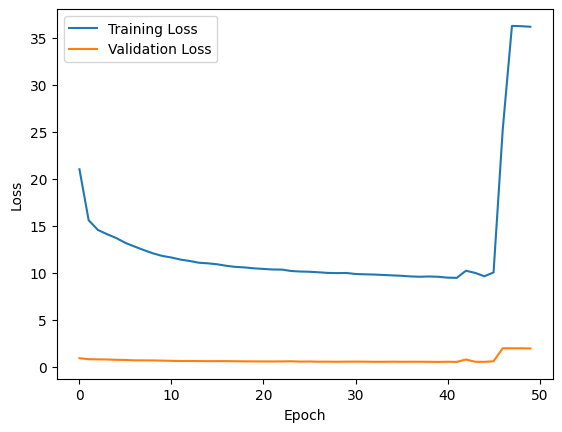

In [4]:
import matplotlib.pyplot as plt
plt.plot(training_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# ============================
# Flow model definition
# ============================

# use gated linear units, such that each layer in the
# net is conditioned on theta and t while x is the main input

# class GLULayer(eqx.Module):
#     lin_x: eqx.nn.Linear    # processes x
#     lin_gate: eqx.nn.Linear # processes (theta, t)

#     def __init__(self, dim_x, dim_theta_t, out_dim, key):
#         key1, key2 = jax.random.split(key)
#         self.lin_x = eqx.nn.Linear(dim_x, out_dim, key=key1)
#         self.lin_gate = eqx.nn.Linear(dim_theta_t, out_dim, key=key2)

#     def __call__(self, x, theta_t):
#         # x-stream
#         h_x = self.lin_x(x)
#         # gating stream
#         gate = jax.nn.sigmoid(self.lin_gate(theta_t))
#         # gated output
#         return h_x * gate


# class Flow(eqx.Module):
#     layers: list
#     final: eqx.nn.Linear

#     def __init__(self, dim_theta, dim_x, key, h: int = 512, depth: int = 3):
#         keys = jax.random.split(key, depth + 1)
#         self.layers = [
#             GLULayer(dim_x if i == 0 else h, dim_theta + 1, h, keys[i])
#             for i in range(depth)
#         ]
#         self.final = eqx.nn.Linear(h, dim_theta, key=keys[-1])

#     def __call__(self, theta, x, t):
#         t = jnp.atleast_1d(t)
#         theta_t = jnp.concatenate([theta, t], axis=-1)
#         out = x
#         for layer in self.layers:
#             out = layer(out, theta_t)
#         return self.final(out)


# ============================
# Loss function
# ============================

@eqx.filter_jit
def loss_fn(flow_params, theta, x_obs, t, v_target):
    flow_model = eqx.combine(flow_params, flow_architecture)
    v_pred = jax.vmap(flow_model)(theta, x_obs, t)
    loss = jnp.mean((v_pred - v_target) ** 2)
    return loss

# ============================
# Optimizer
# ============================

learning_rate = 1e-3
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(flow_params)

# ============================
# Training step
# ============================

@eqx.filter_jit
def train_step(flow_params, opt_state, source_theta, target_theta, x_obs, time):
    """
    Performs one optimization step.
    """
    v_target = target_theta - source_theta
    theta_eval = source_theta + v_target * time

    sigma_min = 0.01

    # from the reference papers, for optimal transport gaussian paths
    # v_target = (target_theta - (1 - sigma_min) * theta_eval) / (1 - (1 - sigma_min) * time)

    loss_value, grads = eqx.filter_value_and_grad(loss_fn)(
        flow_params, theta_eval, x_obs, time, v_target
    )
    updates, opt_state = optimizer.update(grads, opt_state, flow_params)
    flow_params = eqx.apply_updates(flow_params, updates)
    return flow_params, opt_state, loss_value

# ============================
# Training loop
# ============================

print("Starting training with optax...")
num_steps = 9000
batch_size = 1024
losses = []

trained_params = flow_params
best_loss = float('inf')
best_params = trained_params

start_time = timer()
pbar = tqdm(range(num_steps))

for step in pbar:

    key, sk1, sk2, sk3 = jax.random.split(key, 4)

    # start from standard normal
    source_theta = jax.random.normal(sk1, (batch_size, 4))

    # theta from prior
    target_theta = jax.random.normal(sk2, (batch_size, 4)) * jnp.sqrt(sigma2_theta) + mu_theta

    # corresponding observations
    x_obs = jax.vmap(theoretical_observation)(target_theta)

    # while x_obs contains any nans, resample
    while jnp.isnan(x_obs).any():
        key, sk1, sk2, sk3 = jax.random.split(key, 4)
        target_theta = jax.random.normal(sk2, (batch_size, 4)) * jnp.sqrt(sigma2_theta) + mu_theta
        x_obs = jax.vmap(theoretical_observation)(target_theta)

    time = jax.random.uniform(sk3, (batch_size, 1))

    trained_params, opt_state, loss = train_step(
        trained_params, opt_state, source_theta, target_theta, x_obs, time
    )

    losses.append(loss)

    # removed best params logic, does not
    # make sense in this context, I think
    best_params = trained_params

    pbar.set_description(f"Step {step+1}/{num_steps} | Loss: {loss:.2e}")

trained_params = best_params
end_time = timer()
print(f"Training finished in {end_time - start_time:.2f} seconds.")

# Combine trained params and architecture into a callable flow model
flow_model = eqx.combine(trained_params, flow_architecture)
flow_model = jax.vmap(flow_model)

# Midpoint RK2 stepper for one time step
def rk2_step_flow(theta, x_obs, t, dt):
    v1 = flow_model(theta, x_obs, jnp.full((theta.shape[0], 1), t))
    mid_theta = theta + 0.5 * dt * v1
    v2 = flow_model(mid_theta, x_obs, jnp.full((theta.shape[0], 1), t + 0.5 * dt))
    return theta + dt * v2